In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


# Customer Review Analysis

## Business Problem
Analyse customer reviews to identify dissatisfaction and improve product performance.

In [ ]:
# Remove unwanted column, rows missing key fields, duplicates if there is any
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna(subset=["Review Text", "Department Name", "Class Name", "Age", "Rating"])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())

(22627, 10)
Clothing ID                   0
Age                           0
Title                      2965
Review Text                   0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                 0
Department Name               0
Class Name                    0
dtype: int64


# Feature engineering

In [6]:

bins = [0, 24, 34, 44, 54, 100]
labels = ["18-24", "25-34", "35-44", "45-54", "55+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)


def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Rating"].apply(get_sentiment)
df["Recommended"] = df["Recommended IND"].map({1: "Yes", 0: "No"})
df["Review Length"] = df["Review Text"].astype(str).apply(len)

df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Age Group,Sentiment,Recommended,Review Length
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,25-34,Positive,Yes,53
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,25-34,Positive,Yes,303
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,55+,Neutral,No,500
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,45-54,Positive,Yes,124
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,45-54,Positive,Yes,192


In [8]:
df.to_csv("data/cleaned/cleaned_fashion_data.csv", index=False)
print("Cleaned file saved successfully.")

Cleaned file saved successfully.


# KPI

In [9]:
total_reviews = len(df)
avg_rating = df["Rating"].mean()
recommendation_rate = df["Recommended IND"].mean() * 100
negative_review_rate = (df["Rating"] <= 2).mean() * 100
avg_feedback = df["Positive Feedback Count"].mean()

print("Total Reviews:", total_reviews)
print("Average Rating:", round(avg_rating, 2))
print("Recommendation Rate:", round(recommendation_rate, 2), "%")
print("Negative Review Rate:", round(negative_review_rate, 2), "%")
print("Average Positive Feedback Count:", round(avg_feedback, 2))

Total Reviews: 22627
Average Rating: 4.18
Recommendation Rate: 81.88 %
Negative Review Rate: 10.47 %
Average Positive Feedback Count: 2.63


# Analysis

## Ratings by department

In [10]:
dept_rating = (
    df.groupby("Department Name")["Rating"]
    .mean()
    .sort_values()
)

print(dept_rating)

Department Name
Trend       3.838983
Dresses     4.138812
Tops        4.157743
Jackets     4.254491
Intimate    4.271022
Bottoms     4.278612
Name: Rating, dtype: float64


## Recommendation rate by class

In [11]:
class_recommendation = (
    df.groupby("Class Name")["Recommended IND"]
    .mean()
    .sort_values()
    * 100
)

print(class_recommendation)

Class Name
Trend              74.576271
Swim               79.518072
Sweaters           79.710145
Dresses            80.520749
Blouses            80.657057
Outerwear          81.191223
Knits              81.236489
Pants              83.259259
Fine gauge         83.286119
Shorts             83.881579
Skirts             84.163898
Jackets            84.333821
Legwear            85.443038
Sleep              85.514019
Intimates          85.714286
Lounge             85.799701
Layering           87.878788
Jeans              87.941976
Chemises          100.000000
Casual bottoms    100.000000
Name: Recommended IND, dtype: float64


## Ratings by age group

In [12]:
age_group_rating = df.groupby("Age Group")["Rating"].mean()
print(age_group_rating)

Age Group
18-24    4.325635
25-34    4.119177
35-44    4.169786
45-54    4.157490
55+      4.277339
Name: Rating, dtype: float64


/var/folders/pf/pcknrfgx26s97_2l_5tqj6_00000gn/T/ipykernel_2921/157763759.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_rating = df.groupby("Age Group")["Rating"].mean()


## Recommendation rate by age group

In [13]:
age_group_recommendation = df.groupby("Age Group")["Recommended IND"].mean() * 100
print(age_group_recommendation)

Age Group
18-24    86.489607
25-34    79.391006
35-44    81.297967
45-54    81.781377
55+      84.825254
Name: Recommended IND, dtype: float64


/var/folders/pf/pcknrfgx26s97_2l_5tqj6_00000gn/T/ipykernel_2921/2051220432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_recommendation = df.groupby("Age Group")["Recommended IND"].mean() * 100


## Helpful votes by sentiment

In [14]:
feedback_by_sentiment = df.groupby("Sentiment")["Positive Feedback Count"].mean()
print(feedback_by_sentiment)

Sentiment
Negative    3.425316
Neutral     3.198725
Positive    2.432259
Name: Positive Feedback Count, dtype: float64


# Text Analysis

In [15]:
# negative review keywords
negative_reviews = df[df["Sentiment"] == "Negative"]["Review Text"].dropna().astype(str)

text = " ".join(negative_reviews).lower()
words = re.findall(r'\b[a-z]+\b', text)

stopwords = {
    "the", "and", "a", "to", "is", "it", "of", "for", "this", "that", "in", "on",
    "was", "with", "my", "but", "not", "so", "i", "had", "very", "too", "be",
    "as", "are", "have", "they", "you", "at", "an", "or", "if", "from", "them",
    "just", "me", "out", "all", "would", "when", "like", "there", "one", "wear"
}

filtered_words = [word for word in words if word not in stopwords and len(word) > 2]

common_negative_words = Counter(filtered_words).most_common(20)
print(common_negative_words)

[('dress', 1123), ('top', 830), ('fabric', 712), ('fit', 687), ('size', 677), ('back', 615), ('small', 518), ('look', 516), ('ordered', 512), ('really', 474), ('love', 458), ('shirt', 442), ('material', 428), ('looks', 400), ('much', 382), ('color', 380), ('looked', 376), ('even', 374), ('way', 367), ('also', 365)]


# Average Rating by department

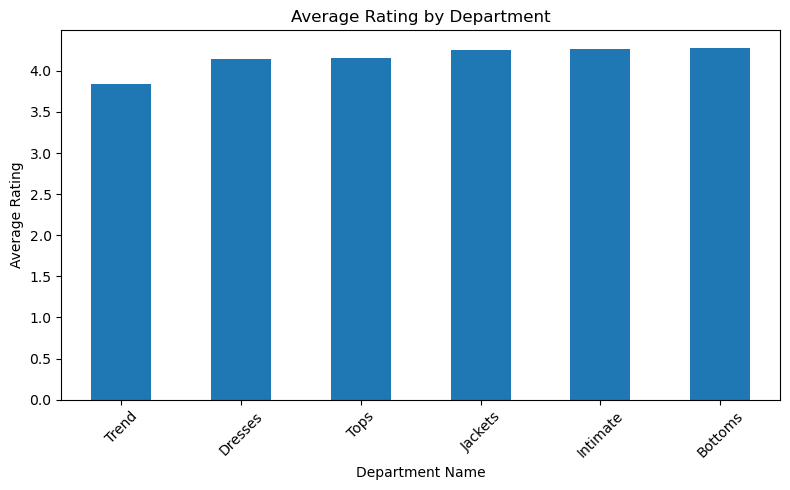

In [16]:
dept_rating.plot(kind="bar", figsize=(8, 5))
plt.title("Average Rating by Department")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Recommendation rate by age group

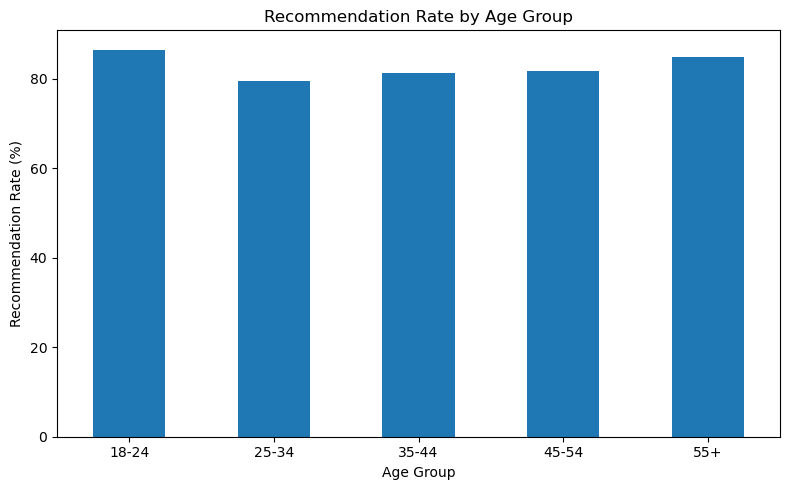

In [17]:
age_group_recommendation.plot(kind="bar", figsize=(8, 5))
plt.title("Recommendation Rate by Age Group")
plt.ylabel("Recommendation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Average helpful votes by sentiment

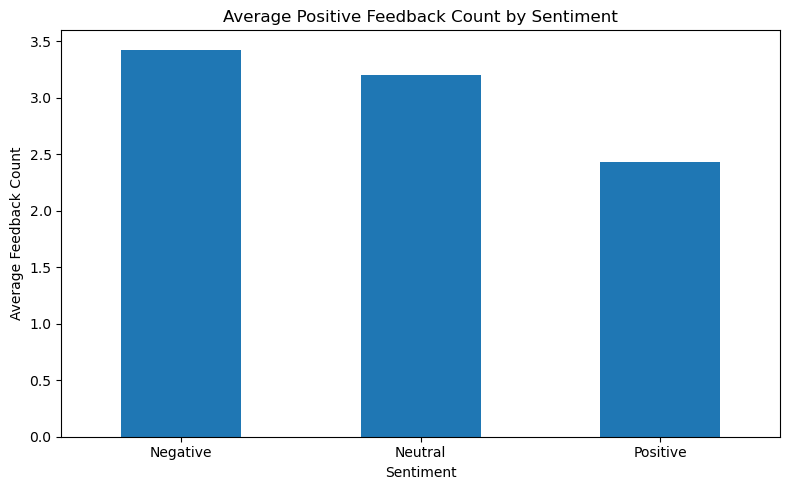

In [18]:
feedback_by_sentiment.plot(kind="bar", figsize=(8, 5))
plt.title("Average Positive Feedback Count by Sentiment")
plt.ylabel("Average Feedback Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()